# Hubble (1929): Expansion of the Universe

Edwin Hubble is famous for his observation that the universe is expanding (or more technically that galaxies are moving away from Earth at speeds proportional to their distance). From this observation comes Hubble's Law and Hubble's Constant. In the example, we will repeat Hubble's analysis but using modern estimating equations

The corresponding data for this analysis can be obtained from the R package `gamair`.

## Setup

In [12]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import delicatessen as deli
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_regression, ee_robust_regression

print("NumPy version:       ", np.__version__)
print("SciPy version:       ", sp.__version__)
print("Pandas version:      ", pd.__version__)
print("Matplotlib version:  ", matplotlib.__version__)
print("Delicatessen version:", deli.__version__)

NumPy version:        2.3.5
SciPy version:        1.16.3
Pandas version:       2.3.3
Matplotlib version:   3.10.8
Delicatessen version: 4.2


In [4]:
d = pd.read_csv("data/hubble.csv")

This data set is consists of observations of the distances (`x`) and velocities (`y`) for 24 galaxies containing Cepheid stars.

The following code plots the observed data points

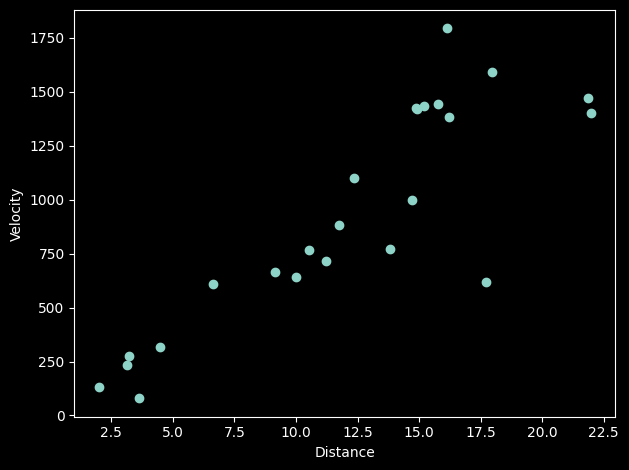

In [6]:
plt.plot(d['x'], d['y'], 'o')
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.tight_layout()

As remarked by Hubble, the relationship looks pretty linear. As done before us, we will fit a linear regression model to these data points

## Linear Regression

The following code fits a linear regression model. As with Hubble, we will fit a model that does *not* include an intercept term. This is done in `delicatessen` by modifying the specified design matrix in `X`. Given that we have relatively few data points, we will also apply a finite-sample correction to the sandwich variance estimator. 

In [21]:
def psi_lr(theta):
    return ee_regression(theta=theta, X=d[['x']], y=d['y'], model='linear')

In [22]:
estr1 = MEstimator(psi_lr, init=[0., ], finite_correction='HC1')
estr1.estimate()

In [23]:
estr1.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          24 | No. Parameters:              1
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       HC1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   76.58     4.93    15.54    66.38    86.78     0.00    43.05 


This estimate is the Hubble Constant.

From the Hubble Constant, we can estimate the age of the universe. To do that, we simply take the inverse of the Hubble Constant (and convert units). However, simply inverting the Hubble Constant does not directly give us the variance for the estimated age of the universe. Here, the ability of estimating equations to automate the delta method comes in handy. We can simply stack another estimating equation that applies our transformation.

The following code (re-)estimates the Hubble Constant along with Hubble Time.

In [56]:
def psi_htime(theta):
    h_constant = theta[:1]
    h_time = theta[1]

    # Estimating function for Hubble Constant
    ee_lr = ee_regression(theta=h_constant, X=d[['x']], y=d['y'], model='linear')

    # Estimating function for Hubble Time
    # NOTE: the division by 997.8 is to convert time to billions of years
    ee_htime = 1 - h_constant[0]*h_time/997.8 * np.ones(d.shape[0])

    # Returning stacked estimating functions
    return np.vstack([ee_lr, ee_htime])

In [57]:
estr2 = MEstimator(psi_htime, init=[76., 0], finite_correction='HC1')
estr2.estimate()

In [59]:
estr2.print_results(decimals=1)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          24 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       HC1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
    76.6      5.0     15.2     66.1     87.0      0.0     41.3 
    13.0      0.9     15.2     11.3     14.8      0.0     41.3 


So, the estimated age of the universe is 13.0 billion years (95% CI: 11.3, 14.8).

## Robust Linear Regression

Given that we see some at least one outlier in the previous plot, we might be concerned about our estimates from before. Here, we repeat the process of estimating the Hubble Constant and Time but using robust linear regression to dampen the influence of any outliers. The following code applies this process

In [63]:
def psi_rlr(theta):
    h_constant = theta[:1]
    h_time = theta[1]

    # Estimating function for Hubble Constant
    ee_lr = ee_robust_regression(theta=h_constant, X=d[['x']], y=d['y'], model='linear',
                                 loss='huber', k=10.)

    # Estimating function for Hubble Time
    # NOTE: the division by 997.8 is to convert time to billions of years
    ee_htime = 1 - h_constant[0]*h_time/997.8 * np.ones(d.shape[0])

    # Returning stacked estimating functions
    return np.vstack([ee_lr, ee_htime])

In [64]:
estr3 = MEstimator(psi_rlr, init=[76., 13., ], finite_correction='HC1')
estr3.estimate()

In [65]:
estr3.print_results()

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          24 | No. Parameters:              2
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:       HC1 | Distribution:           t-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
   74.44     4.57    16.29    64.97    83.92     0.00    43.30 
   13.40     0.82    16.29    11.70    15.11     0.00    43.30 


Here, we get a slightly lower estimate for the Hubble Constant (74.4) and an estimated age of the universe of 13.4 billion years (95% CI: 11.7, 15.1). This is fairly close to the modern estimates of the age of the universe (13.787 billion years, Planck Collaboration 2020). It is also well within the random error of our model.

## References

Planck Collaboration (2020). Planck 2018 results. VI. Cosmological parameters. *Astron. Astrophys*, 641, A6.

Hubble E. (1929). A relation between distance and radial velocity among extra-galactic nebulae. *Proceedings of the National Academy of Sciences*, 15(3), 168-173.